### Carrega o dataset MNIST usando o Keras

In [1]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

### Normalizacao das imagens (intervalo [0, 1])

In [2]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

### One hot enconding nos rótulos

In [3]:
# Sobre o nível para a raiz do projeto, para conseguir importar funcoes do /mlp
import sys
sys.path.append('..')

from mlp.losses import one_hot

y_train = one_hot(y_train)
y_test = one_hot(y_test)

### Treino

In [4]:
from mlp.network import MLP
from mlp.optimizers import SGD

mlp = MLP([784, 128, 64, 10])
optimizer = SGD(lr=0.01)

mlp.fit(X_train, y_train, optimizer, epochs=10, batch_size=64)

Epoch 1/10 - Loss: 2.3040 - Acc: 0.1124
Epoch 2/10 - Loss: 2.3022 - Acc: 0.1124
Epoch 3/10 - Loss: 2.2928 - Acc: 0.2667
Epoch 4/10 - Loss: 2.0018 - Acc: 0.5093
Epoch 5/10 - Loss: 1.0114 - Acc: 0.7519
Epoch 6/10 - Loss: 0.6808 - Acc: 0.8063
Epoch 7/10 - Loss: 0.6042 - Acc: 0.8296
Epoch 8/10 - Loss: 0.5534 - Acc: 0.8459
Epoch 9/10 - Loss: 0.4984 - Acc: 0.8680
Epoch 10/10 - Loss: 0.4373 - Acc: 0.8833


### Plots 

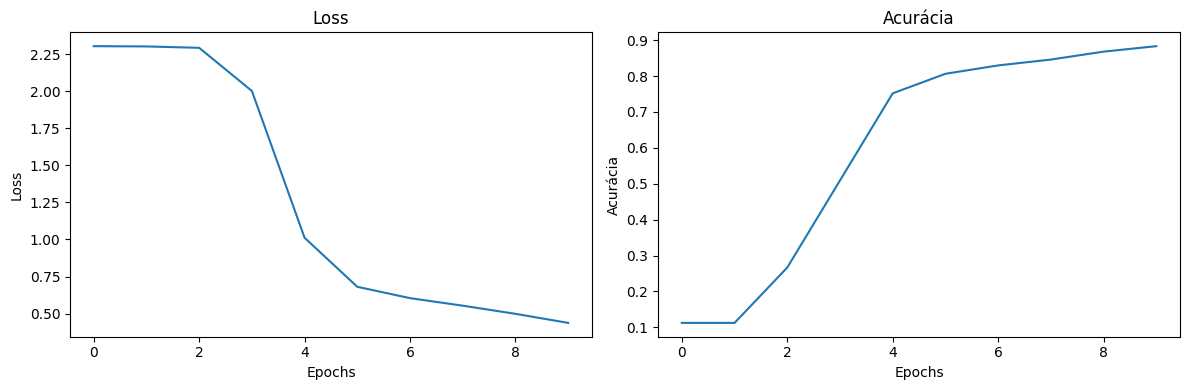

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(mlp.history_loss, label='Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

ax2.plot(mlp.history_acc, label='Acurácia')
ax2.set_title('Acurácia')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Acurácia')

plt.tight_layout()
plt.savefig('../results/loss_accuracy.png')
plt.show()